In [ ]:
%pip install torchgeo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.9/243.9 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
## mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import glob
import os
from collections.abc import Callable

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.figure import Figure
from PIL import Image
from torch import Tensor

from torchgeo.datasets import NonGeoDataset
from torchgeo.datasets.errors import DatasetNotFoundError
from torchgeo.datasets.utils import Path, check_integrity, download_and_extract_archive, extract_archive


class AGB_Reforest(NonGeoDataset):
    """ReforesTree dataset.

    The `ReforesTree <https://github.com/gyrrei/ReforesTree>`__
    dataset contains drone imagery that can be used for tree crown detection,
    tree species classification and Aboveground Biomass (AGB) estimation.

    Dataset features:

    * 100 high resolution RGB drone images at 2 cm/pixel of size 4,000 x 4,000 px
    * more than 4,600 tree crown box annotations
    * tree crown matched with field measurements of diameter at breast height (DBH),
      and computed AGB and carbon values

    Dataset format:

    * images are three-channel pngs
    * annotations are csv file

    Dataset Classes:

    0. other
    1. banana
    2. cacao
    3. citrus
    4. fruit
    5. timber

    If you use this dataset in your research, please cite the following paper:

    * https://arxiv.org/abs/2201.11192

    .. versionadded:: 0.3
    """

    classes = ('other', 'banana', 'cacao', 'citrus', 'fruit', 'timber')
    url = 'https://zenodo.org/records/6813783/files/reforesTree.zip?download=1'

    md5 = 'f6a4a1d8207aeaa5fbab7b21b683a302'
    zipfilename = 'reforesTree.zip'

    def __init__(
        self,
        root: Path = 'data',
        transforms: Callable[[dict[str, Tensor]], dict[str, Tensor]] | None = None,
        download: bool = False,
        checksum: bool = False,
    ) -> None:
        """Initialize a new ReforesTree dataset instance.

        Args:
            root: root directory where dataset can be found
            transforms: a function/transform that takes input sample and its target as
                entry and returns a transformed version
            download: if True, download dataset and store it in the root directory
            checksum: if True, check the MD5 of the downloaded files (may be slow)

        Raises:
            DatasetNotFoundError: If dataset is not found and *download* is False.
        """
        self.root = root
        self.transforms = transforms
        self.checksum = checksum
        self.download = download

        self._verify()

        self.files = self._load_files(self.root)

        self.annot_df = pd.read_csv(os.path.join(root, 'mapping', 'final_dataset.csv'))

        self.classes_grp = self.annot_df['group'].unique()

        self.classes_name = self.annot_df['name'].unique()

        self.class2idx: dict[str, int] = {c: i for i, c in enumerate(sorted(self.classes_grp))}

        self.name2idx: dict[str, int] = {
            name: idx for idx, name in enumerate(sorted(self.classes_name))
        }

    def __getitem__(self, index: int) -> dict[str, Tensor]:
        """Return an index within the dataset.

        Args:
            index: index to return

        Returns:
            data and label at that index
        """
        filepath = self.files[index]

        image = self._load_image(filepath)

        boxes, labels, agb, labels_name = self._load_target(filepath)

        sample = {'image': image, 'bbox_xyxy': boxes, 'label': labels, 'agb': agb, 'label_name': labels_name}

        if self.transforms is not None:
            sample = self.transforms(sample)

        return sample


    def __len__(self) -> int:
        """Return the number of data points in the dataset.

        Returns:
            length of the dataset
        """
        return len(self.files)


    def _load_files(self, root: Path) -> list[str]:
        """Return the paths of the files in the dataset.

        Args:
            root: root dir of dataset

        Returns:
            list of dicts containing paths for each pair of image, annotation
        """
        image_paths = sorted(glob.glob(os.path.join(root, 'tiles', '**', '*.png')))

        # https://github.com/gyrrei/ReforesTree/issues/6
        bad_paths = [
            'Carlos Vera Guevara RGB_15_8425_8305_12425_12305.png',
            'Flora Pluas RGB_3_0_11400_4000_15400.png',
            'Flora Pluas RGB_4_0_11578_4000_15578.png',
            'Flora Pluas RGB_23_12782_11400_16782_15400.png',
            'Flora Pluas RGB_24_12782_11578_16782_15578.png',
        ]
        final_paths = []
        for path in image_paths:
            if os.path.basename(path) not in bad_paths:
                final_paths.append(path)

        return final_paths

    def _load_image(self, path: Path) -> Tensor:
        """Load a single image.

        Args:
            path: path to the image

        Returns:
            the image
        """
        with Image.open(path) as img:
            array: np.typing.NDArray[np.uint8] = np.array(img)
            tensor = torch.from_numpy(array).float()
            # Convert from HxWxC to CxHxW
            tensor = tensor.permute((2, 0, 1))
            return tensor

    def _load_target(self, filepath: Path) -> tuple[Tensor, ...]:
        """Load boxes and labels for a single image.

        Args:
            filepath: image tile filepath

        Returns:
            dictionary containing boxes, label, and agb value
        """
        tile_df = self.annot_df[self.annot_df['img_path'] == os.path.basename(filepath)]

        boxes = torch.Tensor(tile_df[['xmin', 'ymin', 'xmax', 'ymax']].values.tolist())
        labels = torch.Tensor(
            [self.class2idx[label] for label in tile_df['group'].tolist()] ## retrieves the name relative to the correct class.
        ).long()
        labels_name = torch.Tensor(
            [self.name2idx[name] for name in tile_df['name'].tolist()]
        ).long()
        agb = torch.Tensor(tile_df['AGB'].tolist())

        return boxes, labels, agb, labels_name

    def _verify(self) -> None:
        """Checks the integrity of the dataset structure."""
        filepaths = [os.path.join(self.root, dir) for dir in ['tiles', 'mapping']]
        if all([os.path.exists(filepath) for filepath in filepaths]):
            return

        filepath = os.path.join(self.root, self.zipfilename)
        if os.path.isfile(filepath):
            if self.checksum and not check_integrity(filepath, self.md5):
                raise RuntimeError('Dataset found, but corrupted.')
            extract_archive(filepath)
            return

        # Check if the user requested to download the dataset
        if not self.download:
            raise DatasetNotFoundError(self)

        # else download the dataset
        self._download()

    def _download(self) -> None:
        """Download the dataset and extract it."""
        download_and_extract_archive(
            self.url,
            self.root,
            filename=self.zipfilename,
            md5=self.md5 if self.checksum else None,
        )

    def plot(
        self,
        sample: dict[str, Tensor],
        show_titles: bool = True,
        suptitle: str | None = None,
    ) -> Figure:
        """Plot a sample from the dataset.

        Args:
            sample: a sample returned by :meth:`__getitem__`
            show_titles: flag indicating whether to show titles above each panel
            suptitle: optional string to use as a suptitle

        Returns:
            a matplotlib Figure with the rendered sample
        """
        image = sample['image'].permute((1, 2, 0)).numpy()
        ncols = 1
        showing_predictions = 'prediction_bbox_xyxy' in sample
        if showing_predictions:
            ncols += 1

        fig, axs = plt.subplots(ncols=ncols, figsize=(ncols * 10, 10))
        if not showing_predictions:
            axs = [axs]

        axs[0].imshow(image)
        axs[0].axis('off')

        bboxes = [
            patches.Rectangle(
                (bbox[0], bbox[1]),
                bbox[2] - bbox[0],
                bbox[3] - bbox[1],
                linewidth=1,
                edgecolor='r',
                facecolor='none',
            )
            for bbox in sample['bbox_xyxy'].numpy()
        ]
        for bbox in bboxes:
            axs[0].add_patch(bbox)

        if show_titles:
            axs[0].set_title('Ground Truth')

        if showing_predictions:
            axs[1].imshow(image)
            axs[1].axis('off')

            pred_bboxes = [
                patches.Rectangle(
                    (bbox[0], bbox[1]),
                    bbox[2] - bbox[0],
                    bbox[3] - bbox[1],
                    linewidth=1,
                    edgecolor='r',
                    facecolor='none',
                )
                for bbox in sample['prediction_bbox_xyxy'].numpy()
            ]
            for bbox in pred_bboxes:
                axs[1].add_patch(bbox)

            if show_titles:
                axs[1].set_title('Predictions')

        if suptitle is not None:
            plt.suptitle(suptitle)

        return fig

    def plot2(
            self,
            sample: dict[str, Tensor],
            figsize: tuple[int, int] = None,
            show_titles: bool = True,
            suptitle: str | None = None,
            name_or_group: str = 'name',
            color:str ='red',
            ) -> Figure:
            """Plot a sample from the dataset.
                    Args:
                sample: a sample returned by :meth:`__getitem__`
                show_titles: flag indicating whether to show titles above each panel
                suptitle: optional string to use as a suptitle
                classes_group: optional tuple of class names to group together
                    See at 'self.class_grp' object of the class.
                classes_name: list of class names corresponding to labels
                    see at 'self.class_name'.

            Returns:
                a matplotlib Figure with the rendered sample"""

            ## retrieve labels
            try:
                match name_or_group:
                    case 'name':
                        labels_name = sample['label_name'].byte().numpy()
                        classes_name= self.classes_name
                        labels_name = np.array(classes_name)[labels_name]  ## look up class names
                    case 'group':
                        labels_name = sample['label'].byte().numpy()
                        classes_group= self.classes_grp
                        labels_name = np.array(classes_group)[labels_name]  ## look up group names
            except KeyError:
                raise ValueError("name_or_group must be either 'name' or 'group'")

            image = sample['image'].permute((1, 2, 0)).byte().numpy()
            has_preds = 'prediction_bbox_xyxy' in sample
            ncols = 2 if has_preds else 1

            if figsize is None:
                figsize = (ncols * 8, 8)

            # Use constrained_layout to prevent overlapping titles
            fig, axs = plt.subplots(1, ncols, figsize=figsize, constrained_layout=True)

            # If there's only 1 plot, axs is not a list. This standardizes it.
            if ncols == 1:
                axs = [axs]

            ## if grp and names are given
            ## draw bbox and annotation label
            def draw_boxes(ax, boxes, labels_name, color):
                count=0
                for i, bbox in enumerate(boxes.numpy()):
                    # Draw Box
                    ax.add_patch(patches.Rectangle(
                        (bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
                        linewidth=2, edgecolor=color, facecolor='none'
                    ))
                    # Draw Label
                    ax.text(
                        bbox[0], bbox[1], f"{i}-{str(labels_name[i])}",
                        color='white', fontsize=10, fontweight='bold',
                        bbox=dict(facecolor=color, edgecolor='none', pad=1.5)
                    )
                    count += 1
                print(f"Total boxes processed: {count}")

            # Helper to draw on a specific axis
            def draw_on(ax, img, boxes, title, labels_name = labels_name, color=color):
                ax.imshow(img)
                ax.axis('off')
                if show_titles:
                    ax.set_title(title)
                draw_boxes(ax, boxes, labels_name, color)

            # Plot Ground Truth
            draw_on(axs[0], image, sample['bbox_xyxy'], 'Ground Truth')

            # Plot Predictions only if they exist
            if has_preds:
                draw_on(axs[1], image, sample['prediction_bbox_xyxy'], 'Predictions')

            if suptitle is not None:
                plt.suptitle(suptitle)

            return fig

In [ ]:
%matplotlib inline

import timm



In [ ]:
! git clone https://github.com/emanuel-gf/ReforesTree.git

Cloning into 'ReforesTree'...
remote: Enumerating objects: 44, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 44 (delta 9), reused 21 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (44/44), 866.31 KiB | 41.25 MiB/s, done.
Resolving deltas: 100% (9/9), done.


## Exploration of data

In [ ]:
path_root= "/content/drive/MyDrive/Copernicus_lab/dataset"
ds = AGB_Reforest(root=path_root)

Total boxes processed: 21


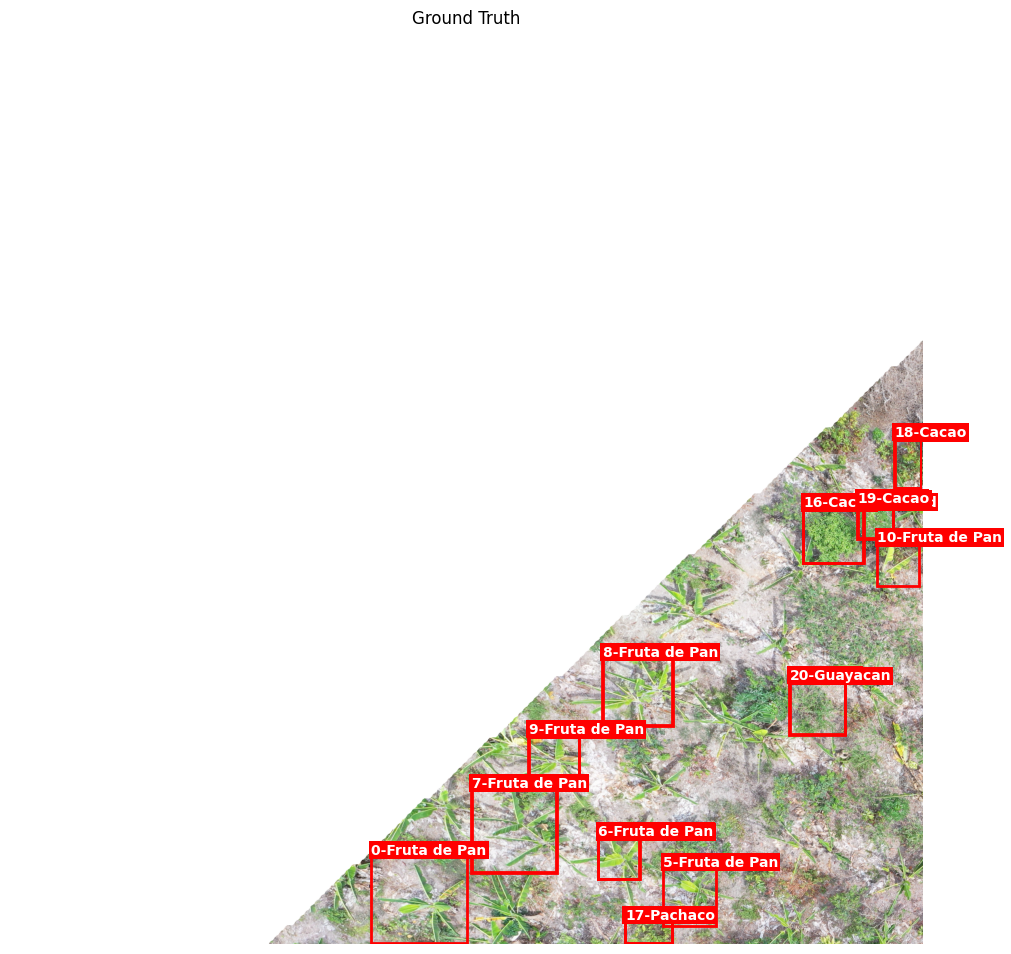

In [ ]:
fig = ds.plot2(ds.__getitem__(0),
         figsize=(10,10))

## resizing

In [ ]:
sample = ds.__getitem__(0)

NameError: name 'ds' is not defined

In [ ]:
sample['image'].unsqueeze(dim=0).shape

torch.Size([1, 3, 4000, 4000])

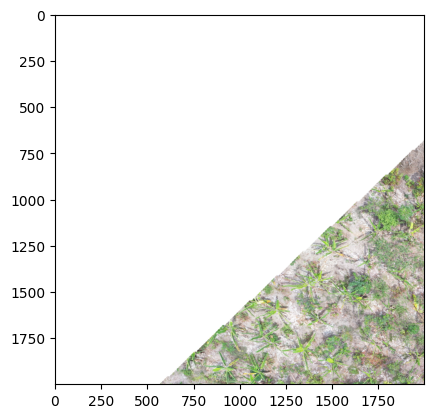

In [ ]:
downsampled = F.interpolate(sample['image'].unsqueeze(dim=0), size=(2000, 2000), mode='bilinear', align_corners=False)

re_img = downsampled.squeeze()

## print downsampled image
plt.imshow(re_img.permute((1, 2, 0)).byte().numpy())

## Model Architecture

In [ ]:
from pprint import pprint
import torch
model_names = timm.list_models("*resnet*",pretrained=True)
pprint(model_names)

['cspresnet50.ra_in1k',
 'eca_resnet33ts.ra2_in1k',
 'ecaresnet26t.ra2_in1k',
 'ecaresnet50d.miil_in1k',
 'ecaresnet50d_pruned.miil_in1k',
 'ecaresnet50t.a1_in1k',
 'ecaresnet50t.a2_in1k',
 'ecaresnet50t.a3_in1k',
 'ecaresnet50t.ra2_in1k',
 'ecaresnet101d.miil_in1k',
 'ecaresnet101d_pruned.miil_in1k',
 'ecaresnet269d.ra2_in1k',
 'ecaresnetlight.miil_in1k',
 'gcresnet33ts.ra2_in1k',
 'gcresnet50t.ra2_in1k',
 'inception_resnet_v2.tf_ens_adv_in1k',
 'inception_resnet_v2.tf_in1k',
 'lambda_resnet26rpt_256.c1_in1k',
 'lambda_resnet26t.c1_in1k',
 'lambda_resnet50ts.a1h_in1k',
 'legacy_seresnet18.in1k',
 'legacy_seresnet34.in1k',
 'legacy_seresnet50.in1k',
 'legacy_seresnet101.in1k',
 'legacy_seresnet152.in1k',
 'nf_resnet50.ra2_in1k',
 'resnet10t.c3_in1k',
 'resnet14t.c3_in1k',
 'resnet18.a1_in1k',
 'resnet18.a2_in1k',
 'resnet18.a3_in1k',
 'resnet18.fb_ssl_yfcc100m_ft_in1k',
 'resnet18.fb_swsl_ig1b_ft_in1k',
 'resnet18.gluon_in1k',
 'resnet18.tv_in1k',
 'resnet18d.ra2_in1k',
 'resnet18d.ra4

In [ ]:
#m.feature_info

[{'num_chs': 64, 'reduction': 2, 'module': 'act1'},
 {'num_chs': 256, 'reduction': 4, 'module': 'layer1'},
 {'num_chs': 512, 'reduction': 8, 'module': 'layer2'},
 {'num_chs': 1024, 'reduction': 16, 'module': 'layer3'},
 {'num_chs': 2048, 'reduction': 32, 'module': 'layer4'}]

In [ ]:
sample = ds.__getitem__(2)

o = m(sample['image'].unsqueeze(dim=0))
for ob in o:
  print(ob.shape)

In [ ]:
m = timm.create_model('resnet18.a1_in1k',
                      pretrained=True,
                      features_only=True,
                      global_pool = ''
                      )
sample = ds.__getitem__(2)
o = m(sample['image'].unsqueeze(dim=0))
for ob in o:
  print(ob.shape)

torch.Size([1, 64, 2000, 2000])
torch.Size([1, 64, 1000, 1000])
torch.Size([1, 128, 500, 500])
torch.Size([1, 256, 250, 250])
torch.Size([1, 512, 125, 125])


In [ ]:
len(o)

5

## Plot feature SPace

tensor org shape:torch.Size([3, 4000, 4000])
torch.Size([1, 64, 2000, 2000])
torch.Size([1, 64, 1000, 1000])
torch.Size([1, 128, 500, 500])
torch.Size([1, 256, 250, 250])
torch.Size([1, 512, 125, 125])


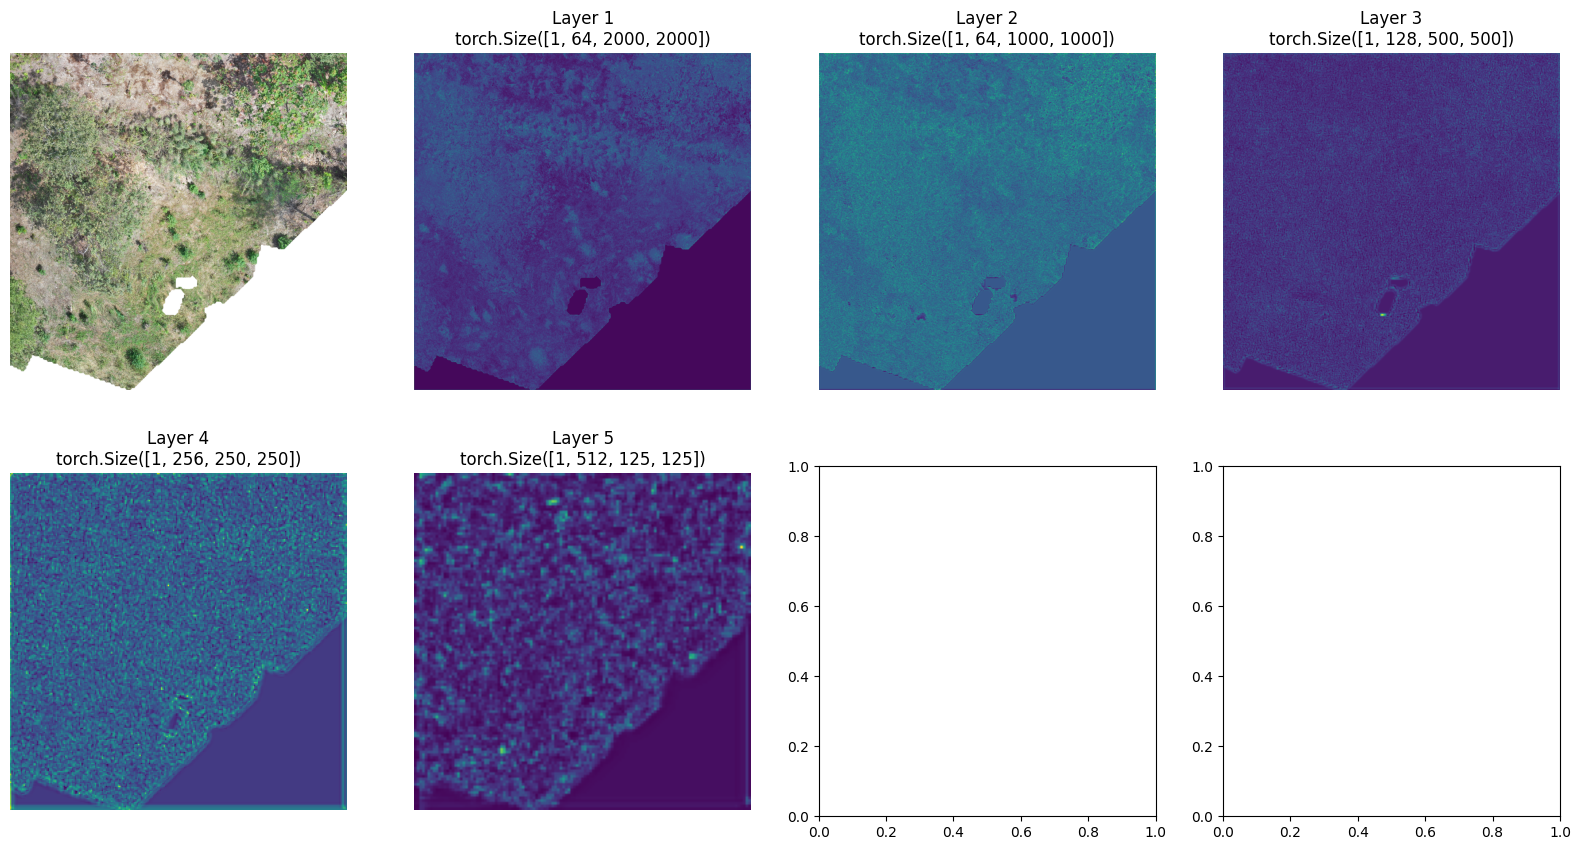

In [ ]:
import matplotlib.pyplot as plt
import torch
import math
import numpy as np
import timm

model = timm.create_model('resnet18.a1_in1k',
                      pretrained=True,
                      features_only=True,
                      global_pool = ''
                      )
sample = ds.__getitem__(2)
print(f"tensor org shape:{sample['image'].shape}")

## get the  feature map
fc = model(sample['image'].unsqueeze(dim=0))

# Move all feature maps to CPU and delete GPU references
fc = [ob.detach().cpu() for ob in fc]
torch.cuda.empty_cache()

for ob in fc:
  print(ob.shape)

def plot_feature_maps(features, original_img):
  """
  Plot feature maps from a model
      ARgs:
      features: List[tensors]. Feature Extraction of  backbone
      original_img: tensor. Original tensor representing the image.
  """
  num_cols = 4
  num_rows = math.ceil((len(features)+1) / num_cols)
  fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 10))
  axes = np.array(axes).flatten()

  # Plot original image
  axes[0].imshow(original_img.permute((1, 2, 0)).byte().numpy())
  axes[0].axis('off')

  # Process and plot each feature map one by one
  for i, fmap in enumerate(features):
      mean_map = torch.mean(fmap, dim=1).squeeze().detach().cpu().numpy()
      axes[i+1].imshow(mean_map, cmap='viridis')
      axes[i+1].set_title(f"Layer {i+1}\n{fmap.shape}")
      axes[i+1].axis('off')
      # Optionally, clear memory after each plot
      del mean_map
  plt.show()

plot_feature_maps(fc, sample['image'])

In [ ]:
plt.close('all')

In [ ]:
# The 'o' variable is a list of tensors of different sizes, so torch.stack will fail.
# Instead of stacking, we should select the appropriate feature map for further processing,
# typically the last one for high-level semantic features.
# Let's print the shapes of the elements in 'o' again to clarify:
for i, feature in enumerate(o):
    print(f"Feature map {i} shape: {feature.shape}")

# If you wanted to combine them, you would need to resize them first, for example:
# resized_features = [F.interpolate(f, size=(16, 16), mode='bilinear', align_corners=False) for f in o]
# combined_features = torch.cat(resized_features, dim=1)
# print(f"Combined features shape: {combined_features.shape}")


RuntimeError: stack expects each tensor to be equal size, but got [1, 64, 256, 256] at entry 0 and [1, 64, 128, 128] at entry 1

In [ ]:
print(f'Feature channels: {m.feature_info.channels()}')

Feature channels: [128, 512, 1024, 2048, 4096]


In [ ]:
print(f'Feature reduction: {m.feature_info.reduction()}')

Feature reduction: [2, 4, 8, 16, 32]


In [ ]:
print(m)

FeatureListNet(
  (stem_conv1): ConvNormAct(
    (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (stem_conv2): ConvNormAct(
    (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (stem_conv3): ConvNormAct(
    (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (stem_pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (stages_0): Sequential(
    (0): BottleneckBlock(
      (shortcut

In [ ]:
## this crash the server
o = m(torch.randn(1, 3, 400, 400))
o.shape

In [ ]:
from decorator import decorate
import torch
import torch.nn.functional as F
import timm
from functools import wraps
from time import time


def extract_features_sliding_window(model, image, patch_size, stride):
    """
    Extract features using sliding window approach
    image: (1, 3, H, W) tensor

    Returns:
      A list of feature tensors, one for each sliding window position.
      tensor shape: (1, C, H_feat, W_feat)
      A global pooling over channel dimension is applied.
    """
    model.eval()
    b, c, h, w = image.shape

    features_list = []

    with torch.no_grad():
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = image[:, :, i:i+patch_size, j:j+patch_size]
                feat = model(patch)  # (1, C, H_feat, W_feat)
                features_list.append(feat)
        print(f"Size of feature list:{len(features_list)}")
        print(f" first element of feature list:{features_list[0].shape}")

    # Aggregate features (e.g., average pooling)
    features = torch.stack(features_list).mean(dim=0) ## Mean over Channel (C,H,W)

    ##return features
    return features

# Usage
model = timm.create_model('resnet18.a1_in1k',
                      pretrained=True,
                      num_classes=0,
                      global_pool='')

## load the sample
sample = ds.__getitem__(3)


## extract embeddings through a sliding window
## and apply global pooling over channel dimension
features = extract_features_sliding_window(model,
                                           sample['image'].unsqueeze(0),
                                           patch_size=1000,
                                           stride=500
                                           )

print(f"Features shape:{features.shape}")

Size of feature list:49
 first element of feature list:torch.Size([1, 512, 32, 32])
Features shape:torch.Size([1, 512, 32, 32])


tensor org shape:torch.Size([3, 4000, 4000])
torch.Size([512, 125, 125])
after pooling:(1, 125, 125)
fc channel mean:(125, 125)


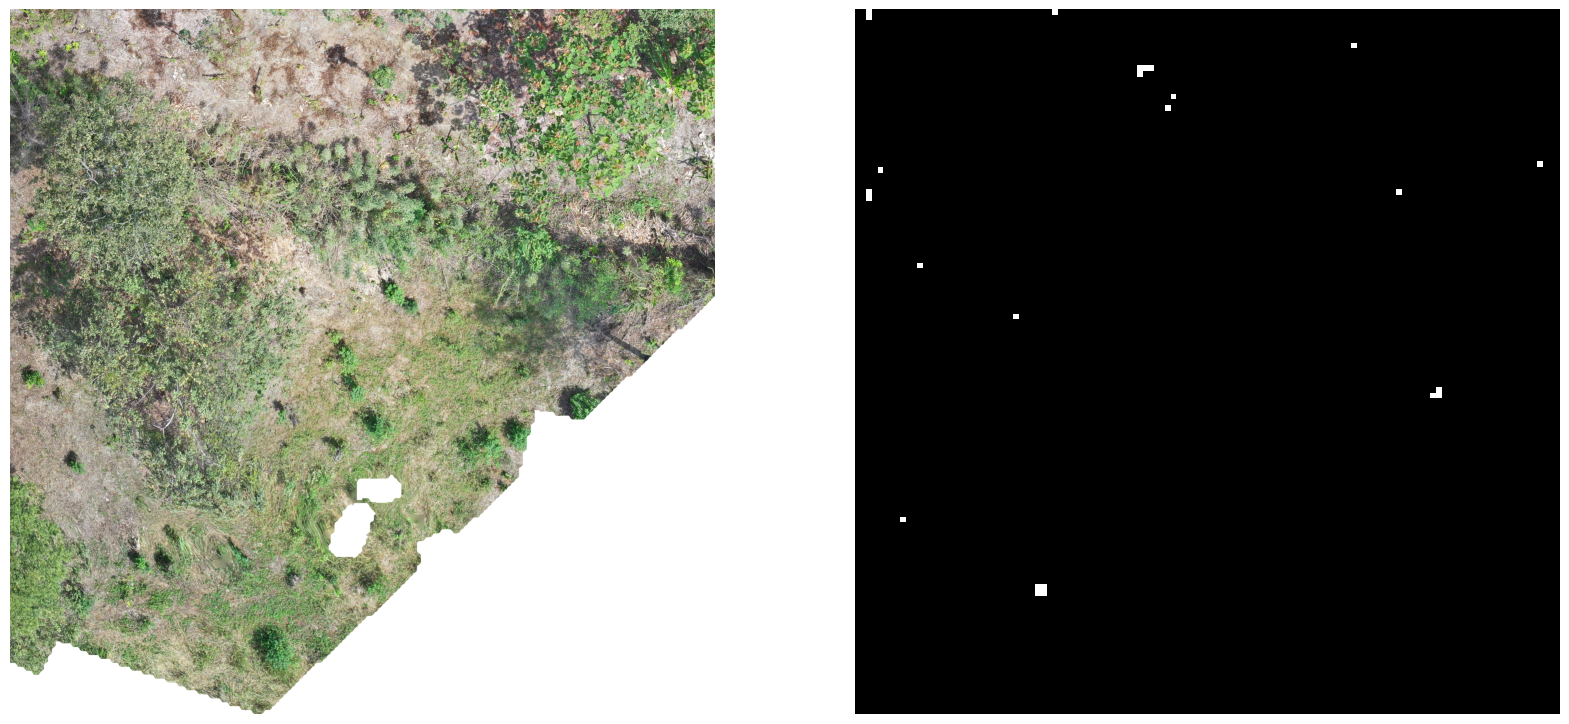

In [ ]:
import matplotlib.pyplot as plt
import torch
import math
import numpy as np
import timm

model = timm.create_model('resnet18.a1_in1k',
                      pretrained=True,
                      num_classes=0,
                      global_pool = ''
                      )
sample = ds.__getitem__(2)
print(f"tensor org shape:{sample['image'].shape}")

## get the  feature map
fc = model(sample['image'].unsqueeze(dim=0))

# Move all feature maps to CPU and delete GPU references
fc = fc.detach().cpu()
torch.cuda.empty_cache()

for ob in fc:
  print(ob.shape)

## make a global pooling to be able of plotting
fc = torch.mean(fc, dim=1).byte().numpy() ## C,H,W
print(f"after pooling:{fc.shape}")

fc_channel_mean = fc[0] ## retrieve the first channel and plot grayscale
print(f"fc channel mean:{fc_channel_mean.shape}")
def plot_feature_maps(features, original_img):
  """
  Plot feature maps from a model
      ARgs:
      features: Array. Feature Extraction of  backbone
      original_img: tensor. Original tensor representing the image.
  """
  fig, axes = plt.subplots(1, 2, figsize=(20, 10))
  axes = np.array(axes).flatten()

  # Plot original image
  axes[1].imshow(features, cmap='gray')
  axes[1].axis('off')

  axes[0].imshow(original_img.permute((1, 2, 0)).byte().numpy())
  axes[0].axis('off')
  plt.show()

plot_feature_maps(fc_channel_mean, sample['image'])

In [ ]:
fc.shape
print(f"Shape: {fc.shape}")
print(f"Min value: {fc.min().item():.4f}")
print(f"Max value: {fc.max().item():.4f}")
print(f"Mean value: {fc.mean().item():.4f}")
print(f"Std value: {fc.std().item():.4f}")

Shape: torch.Size([1, 125, 125])
Min value: 0.0000
Max value: 1.7289
Mean value: 0.2122
Std value: 0.1593


In [ ]:
fc[0]

tensor([[0.0285, 0.0959, 1.0780,  ..., 0.2630, 0.1519, 0.0260],
        [0.0250, 0.2815, 1.1015,  ..., 0.1349, 0.2506, 0.1542],
        [0.0651, 0.1613, 0.3969,  ..., 0.0946, 0.2226, 0.1854],
        ...,
        [0.0442, 0.0426, 0.1864,  ..., 0.1081, 0.4201, 0.2729],
        [0.0264, 0.0241, 0.1977,  ..., 0.0519, 0.1454, 0.0523],
        [0.0286, 0.0380, 0.1933,  ..., 0.0395, 0.0470, 0.0428]])

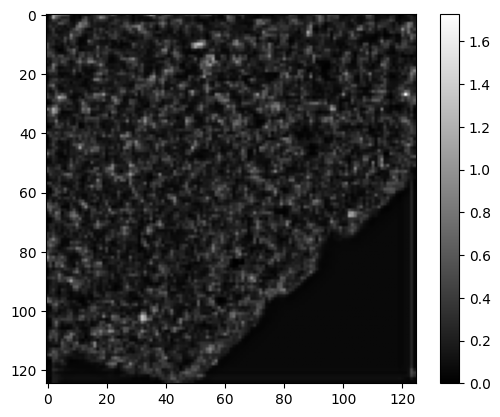

In [ ]:
plt.imshow(fc[0], cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
spatial_scale = feature_map.shape[-1] / image.shape[-1]

        # tree_features shape: [N, 512, 7, 7]
        tree_features = roi_align(feature_map,
                                  list(bboxes),
                                  output_size=(self.roi_pool_size, self.roi_pool_size),
                                  spatial_scale=spatial_scale
                                  )

## Improved approach:

In [ ]:
import torch
import timm
## this for whole 4000x4000 tile

# 1. Use half precision to save 50% RAM
model = timm.create_model('resnet18.a1_in1k', pretrained=True, num_classes=0, global_pool='')
model.half().cuda().eval()

sample_img = sample['image'].unsqueeze(0).half().cuda()

# 2. Use inference_mode (faster/more memory efficient than no_grad)
with torch.inference_mode():
    features = model(sample_img)

    # 3. Move to CPU immediately and shrink
    # Instead of storing the whole 512-channel map, pool it ON THE GPU first
    features_pooled = torch.mean(features, dim=1).cpu()

# Clear cache
del features
torch.cuda.empty_cache()

KeyboardInterrupt: 

In [ ]:
## this for windowindg
import torch
import math

def reconstruct_feature_map(model, image, patch_size, stride):
    """
    Processes image in tiles and reconstructs the full feature map.
    Optimized for low RAM by avoiding torch.stack.
    """
    model.eval().cuda()
    b, c, h, w = image.shape

    # 1. Determine the downsampling factor of the model
    # For ResNet18, a 1000x1000 input yields a 32x32 output (Factor = 31.25, effectively 32)
    with torch.no_grad():
        dummy_input = torch.zeros((1, 3, patch_size, patch_size)).cuda()
        dummy_output = model(dummy_input)
        feat_c, feat_h, feat_w = dummy_output.shape[1:]
        scale = patch_size / feat_h  # Downsampling ratio (usually 32 for ResNet)

    # 2. Pre-allocate the full feature map canvas on CPU to save GPU RAM
    full_feat_h = math.ceil(h / scale)
    full_feat_w = math.ceil(w / scale)
    # We use a count_map to handle overlapping areas (averaging them)
    canvas = torch.zeros((1, feat_c, full_feat_h, full_feat_w), dtype=torch.float32)
    count_map = torch.zeros((1, 1, full_feat_h, full_feat_w), dtype=torch.float32)

    print(f"Allocated canvas size: {canvas.shape}")

    with torch.inference_mode():
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                # Extract and process patch
                patch = image[:, :, i:i+patch_size, j:j+patch_size].cuda()
                feat = model(patch).cpu() # Move to CPU immediately

                # Calculate placement indices on the feature map
                start_i = int(i / scale)
                start_j = int(j / scale)
                end_i = start_i + feat_h
                end_j = start_j + feat_w

                # Add features to canvas and update count for averaging
                canvas[:, :, start_i:end_i, start_j:end_j] += feat
                count_map[:, :, start_i:end_i, start_j:end_j] += 1.0

    # 3. Average the overlapping regions
    features = canvas / count_map
    return features

# Usage
# Assuming 'sample' is your 4000x4000 image
features = reconstruct_feature_map(
    model,
    sample['image'].unsqueeze(0),
    patch_size=1000,
    stride=500
)

print(f"Final Reconstructed Shape: {features.shape}")

### timm

In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import timm

class AGBVisualRegressor(nn.Module):
    def __init__(self, output_dim=1):
        super().__init__()
        # backbone
        self.backbone = timm.create_model(
            'resnet101.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool='',
            features_only=True # Ensure it returns a list of feature maps
        )

        # Get feature dimensions from the last output layer of the backbone
        self.feature_dim = self.backbone.feature_info.channels()[-1]
        self.backbone_reduction = self.backbone.feature_info.reduction()[-1]

        self.roi_pool_size = 7

        # Final Regression Head
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_pool_size * self.roi_pool_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim) # Predicts AGB for ONE tree
        )

    def forward(self, image, bboxes):
        """
        image: [1, 3, H, W] tensor
        bboxes: List of [N, 4] tensors for roi_align
        """
        # Step 1: Extract feature map from the whole image
        # self.backbone(image) returns a list of feature maps. We take the last one.
        feature_map_list = self.backbone(image)
        feature_map = feature_map_list[-1]

        # Step 2: Crop features based on bboxes
        # roi_align expects a list of tensors, one for each image in the batch
        # We also need to scale coordinates because the feature map is smaller than the image
        # spatial_scale = feature_map_height / original_image_height
        # Since the feature map height is original_image_height / self.backbone_reduction
        spatial_scale = 1.0 / self.backbone_reduction

        # tree_features shape: [N, self.feature_dim, roi_pool_size, roi_pool_size]
        tree_features = roi_align(
            feature_map,
            bboxes,
            output_size=(self.roi_pool_size, self.roi_pool_size),
            spatial_scale=spatial_scale
        )

        # Step 3: Predict AGB for each tree
        tree_features = tree_features.view(tree_features.size(0), -1)
        individual_agb = self.regressor(tree_features) # [N, output_dim]

        # Step 4: Sum the AGB for the entire patch
        total_patch_agb = torch.sum(individual_agb)

        return total_patch_agb


## improve class

In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import timm

class AGBVisualRegressor(nn.Module):
    def __init__(self, output_dim=1):
        super().__init__()
        # Backbone: ResNet18 is lightweight and fast
        # num_classes=0 + global_pool='' returns the [1, 512, H/32, W/32] feature map
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        ).half().cuda().eval()

        self.feature_dim = 512
        self.reduction = 32  # ResNet18 total stride
        self.roi_size = 7

        # Regression Head
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        ).half().cuda()

    @torch.inference_mode()
    def forward(self, image, bboxes, patch_size=1000):
        """
        image: [1, 3, 4000, 4000] Tensor on CPU
        bboxes: List of [N, 4] Tensors on GPU
        """
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # 1. Pre-allocate Canvas on CPU (saves GPU VRAM)
        # 512 * 125 * 125 * 2 bytes (FP16) = ~16MB. Extremely safe for 12GB RAM.
        full_feature_map = torch.zeros((b, self.feature_dim, out_h, out_w),
                                      dtype=torch.float16, device='cpu')

        # 2. Tiled Extraction Loop
        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                # Extract patch, move to GPU, convert to half
                patch = image[:, :, i:i+patch_size, j:j+patch_size].cuda().half()

                # Get last layer features directly
                feat = self.backbone(patch)

                # Place in canvas and move to CPU immediately
                si, sj = i // self.reduction, j // self.reduction
                ei, ej = si + feat.shape[2], sj + feat.shape[3]
                full_feature_map[:, :, si:ei, sj:ej] = feat.cpu()

                # Explicitly clear patch from VRAM
                del patch, feat
                torch.cuda.empty_cache()

        # 3. RoI Align
        # Transfer the full map back to GPU for the fast RoI operations
        spatial_scale = 1.0 / self.reduction
        tree_features = roi_align(
            full_feature_map.cuda().half(),
            bboxes,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=spatial_scale
        )

        # 4. Predict and Sum
        tree_features = tree_features.flatten(1)
        individual_agb = self.regressor(tree_features)
        total_patch_agb = torch.sum(individual_agb)

        return total_patch_agb, individual_agb

# --- Usage Example ---
model = AGBVisualRegressor()

# Keep the big image on CPU as float32/uint8 to save VRAM
# Only patches go to GPU
img_cpu = sample['image'].unsqueeze(0)
bboxes_gpu = [sample['bboxes'].cuda()] # RoI align expects a list of tensors
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import timm

class AGBTrainableRegressor(nn.Module):
    def __init__(self, output_dim=1, freeze_backbone=True):
        super().__init__()
        # Backbone (ResNet18)
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        ).half().cuda()

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32
        self.roi_size = 7

        # MLP Regressor (This is what we train)
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        ).half().cuda()

    def get_roi_features(self, image, bboxes, patch_size=1000):
        """
        Extracts features for specific ROIs without keeping the
        entire feature map's gradient in memory.
        """
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # We still use a canvas, but we use it as a 'container'
        # for features that we will then RoI Align from.
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float16, device='cuda')

        # We use no_grad for the backbone extraction to save massive RAM
        with torch.no_grad():
            for i in range(0, h, patch_size):
                for j in range(0, w, patch_size):
                    patch = image[:, :, i:i+patch_size, j:j+patch_size].cuda().half()
                    feat = self.backbone(patch)

                    si, sj = i // self.reduction, j // self.reduction
                    ei, ej = si + feat.shape[2], sj + feat.shape[3]
                    canvas[:, :, si:ei, sj:ej] = feat
                    del patch, feat

        # NOW: RoI Align from the canvas.
        # Even though canvas was made with no_grad, we can still train the MLP
        # because the RoI features will be passed into the trainable MLP.
        roi_feats = roi_align(
            canvas,
            bboxes,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0/self.reduction
        )
        return roi_feats

    def forward(self, image, bboxes):
        # 1. Get the features (Backbone part is frozen/no_grad)
        # roi_feats shape: [N_trees, 512, 7, 7]
        roi_feats = self.get_roi_features(image, bboxes)

        # 2. Flatten and pass through the TRAINABLE MLP
        roi_feats = roi_feats.flatten(1)

        # The gradients will start tracking from here
        individual_agb = self.regressor(roi_feats)

        return individual_agb # Return per-tree predictions

# --- Training Loop Example ---
model = AGBTrainableRegressor(freeze_backbone=True)
optimizer = torch.optim.Adam(model.regressor.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Single training step
model.regressor.train()
optimizer.zero_grad()

# individual_agb: [N_trees, 1]
predictions = model(img_cpu, bboxes_gpu)

# Assuming target_agb is a [N_trees, 1] tensor of ground truth
loss = criterion(predictions, target_agb)
loss.backward() # Backprop only goes through the MLP, not the backbone
optimizer.step()
total_agb, tree_list = model(img_cpu, bboxes_gpu)

print(f"Total Biomass calculated: {total_agb.item()}")

In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import timm

class AGBTrainableRegressor(nn.Module):
    def __init__(self, output_dim=1, freeze_backbone=True):
        super().__init__()
        # Backbone (ResNet18)
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        ).half().cuda()

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32
        self.roi_size = 7

        # MLP Regressor
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        ).half().cuda()

    def get_roi_features(self, image, bboxes, patch_size=1000):
        """
        Extracts features for specific ROIs without keeping the
        entire feature map's gradient in memory.
        """
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # We still use a canvas, but we use it as a 'container'
        # for features that we will then RoI Align from.
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float16, device='cuda')

        # We use no_grad for the backbone extraction to save massive RAM
        with torch.no_grad():
            for i in range(0, h, patch_size):
                for j in range(0, w, patch_size):
                    patch = image[:, :, i:i+patch_size, j:j+patch_size].cuda().half()
                    feat = self.backbone(patch)

                    si, sj = i // self.reduction, j // self.reduction
                    ei, ej = si + feat.shape[2], sj + feat.shape[3]
                    canvas[:, :, si:ei, sj:ej] = feat
                    del patch, feat

        # NOW: RoI Align from the canvas.
        # Even though canvas was made with no_grad, we can still train the MLP
        # because the RoI features will be passed into the trainable MLP.
        roi_feats = roi_align(
            canvas,
            bboxes,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0/self.reduction
        )
        return roi_feats

    def forward(self, image, bboxes):
        # 1. Get the features (Backbone part is frozen/no_grad)
        # roi_feats shape: [N_trees, 512, 7, 7]
        roi_feats = self.get_roi_features(image, bboxes)

        # 2. Flatten and pass through the TRAINABLE MLP
        roi_feats = roi_feats.flatten(1)

        # The gradients will start tracking from here
        individual_agb = self.regressor(roi_feats)

        return individual_agb # Return per-tree predictions

# --- Training Loop Example ---
model = AGBTrainableRegressor(freeze_backbone=True)
optimizer = torch.optim.Adam(model.regressor.parameters(), lr=1e-4)
criterion = nn.MSELoss()

# Single training step
model.regressor.train()
optimizer.zero_grad()

# individual_agb: [N_trees, 1]
predictions = model(img_cpu, bboxes_gpu)

# Assuming target_agb is a [N_trees, 1] tensor of ground truth
loss = criterion(predictions, target_agb)
loss.backward() # Backprop only goes through the MLP, not the backbone
optimizer.step()

## second improving of the class


In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import roi_align
import timm

class AGBTrainableRegressor(nn.Module):
    def __init__(self, output_dim=1, freeze_backbone=True):
        super().__init__()
        # Backbone ResNet18 - Lean & Fast
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        ).half().cuda()

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32
        self.roi_size = 7

        # MLP Regressor: Input is pooled tree features, output is biomass (scalar)
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        ).half().cuda()

    @torch.inference_mode()
    def _get_features_tiled(self, image, patch_size=1000):
        """Internal helper to extract features without tracking gradients."""
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # Allocate canvas on GPU - ResNet18 features for 4000x4000 fit in 12GB VRAM (~64MB)
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float16, device='cuda')

        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                patch = image[:, :, i:i+patch_size, j:j+patch_size].cuda().half()
                feat = self.backbone(patch)

                si, sj = i // self.reduction, j // self.reduction
                ei, ej = si + feat.shape[2], sj + feat.shape[3]
                canvas[:, :, si:ei, sj:ej] = feat
                del patch, feat

        return canvas

    def forward(self, image, bboxes):
        """
        Returns:
            total_agb: Summed biomass for the patch (trainable)
            individual_agbs: Biomass per tree (for analysis)
        """
        # 1. Feature Extraction (Frozen/No Gradients)
        feature_map = self._get_features_tiled(image)

        # 2. RoI Align (Gradients start here for the MLP)
        # We ensure bboxes are on the same device as the feature_map (GPU)
        roi_feats = roi_align(
            feature_map,
            bboxes,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0 / self.reduction
        )

        # 3. Regression Head
        roi_feats = roi_feats.flatten(1)
        individual_agbs = self.regressor(roi_feats) # [N_trees, 1]

        # 4. Global Aggregation
        # Sum the individual tree biomasses to get the patch total
        total_agb = torch.sum(individual_agbs)

        return total_agb, individual_agbs

In [ ]:
model = AGBTrainableRegressor(freeze_backbone=True)
optimizer = torch.optim.Adam(model.regressor.parameters(), lr=1e-4)
criterion = nn.MSELoss()

def train_one_epoch(dataloader):
    model.regressor.train()
    total_loss = 0

    for batch in dataloader:
        # Load data (keeping image on CPU to save 12GB RAM)
        img = batch['image']     # [1, 3, 4000, 4000]
        bboxes = [batch['bboxes'].cuda()] # List of [N, 4]
        target_patch_agb = batch['total_agb'].cuda().half() # Scalar ground truth

        optimizer.zero_grad()

        # Forward pass
        pred_patch_agb, _ = model(img, bboxes)

        # Loss: How close is the sum of trees to the total patch biomass?
        loss = criterion(pred_patch_agb, target_patch_agb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        torch.cuda.empty_cache() # Essential for 12GB limit

    return total_loss / len(dataloader)

@torch.no_grad()
def validate(dataloader):
    model.regressor.eval()
    val_mse = 0

    for batch in dataloader:
        img = batch['image']
        bboxes = [batch['bboxes'].cuda()]
        target_patch_agb = batch['total_agb'].cuda().half()

        pred_patch_agb, _ = model(img, bboxes)

        # Calculate Mean Squared Error
        val_mse += criterion(pred_patch_agb, target_patch_agb).item()

    return val_mse / len(dataloader)

## lightning

In [ ]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torchvision.ops import roi_align
import timm

class AGBTrainableRegressor(pl.LightningModule):
    def __init__(
        self,
        output_dim: int = 1,
        freeze_backbone: bool = True,
        learning_rate: float = 1e-4,
    ):
        super().__init__()
        self.save_hyperparameters()

        # Backbone ResNet18 - Lean & Fast
        self.backbone = timm.create_model(
            'resnet18.a1_in1k',
            pretrained=True,
            num_classes=0,
            global_pool=''
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            self.backbone.eval()

        self.feature_dim = 512
        self.reduction = 32
        self.roi_size = 7

        # MLP Regressor: Input is pooled tree features, output is biomass (scalar)
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_size * self.roi_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

        self.criterion = nn.MSELoss()
        self.learning_rate = learning_rate

    @torch.inference_mode()
    def _get_features_tiled(self, image, patch_size=1000):
        """Internal helper to extract features without tracking gradients."""
        b, c, h, w = image.shape
        out_h, out_w = h // self.reduction, w // self.reduction

        # Allocate canvas on GPU
        canvas = torch.zeros((b, self.feature_dim, out_h, out_w),
                             dtype=torch.float16, device=self.device)

        for i in range(0, h, patch_size):
            for j in range(0, w, patch_size):
                patch = image[:, :, i:i+patch_size, j:j+patch_size].to(self.device).half()
                feat = self.backbone(patch)

                si, sj = i // self.reduction, j // self.reduction
                ei, ej = si + feat.shape[2], sj + feat.shape[3]
                canvas[:, :, si:ei, sj:ej] = feat
                del patch, feat

        return canvas

    def forward(self, image, bboxes):
        """
        Returns:
            total_agb: Summed biomass for the patch (trainable)
            individual_agbs: Biomass per tree (for analysis)
        """
        # 1. Feature Extraction (Frozen/No Gradients)
        feature_map = self._get_features_tiled(image)

        # 2. RoI Align (Gradients start here for the MLP)
        roi_feats = roi_align(
            feature_map,
            bboxes,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=1.0 / self.reduction
        )

        # 3. Regression Head
        roi_feats = roi_feats.flatten(1)
        individual_agbs = self.regressor(roi_feats) # [N_trees, 1]

        # 4. Global Aggregation
        total_agb = torch.sum(individual_agbs)

        return total_agb, individual_agbs

    def training_step(self, batch, batch_idx):
        img = batch['image']
        bboxes = [batch['bboxes'].to(self.device)]
        target_patch_agb = batch['total_agb'].to(self.device).half()

        pred_patch_agb, _ = self(img, bboxes)
        loss = self.criterion(pred_patch_agb, target_patch_agb)

        self.log('train_loss', loss, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img = batch['image']
        bboxes = [batch['bboxes'].to(self.device)]
        target_patch_agb = batch['total_agb'].to(self.device).half()

        pred_patch_agb, _ = self(img, bboxes)
        loss = self.criterion(pred_patch_agb, target_patch_agb)

        self.log('val_loss', loss, prog_bar=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.regressor.parameters(), lr=self.learning_rate)


In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import ModelCheckpoint

# Example usage
model = AGBTrainableRegressor(learning_rate=1e-4)

checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    dirpath='checkpoints/',
    filename='agb-regressor-{epoch:02d}-{val_loss:.2f}'
)

trainer = Trainer(
    max_epochs=10,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    callbacks=[checkpoint_callback],
    log_every_n_steps=10,
)

trainer.fit(model, train_dataloader, val_dataloader)
